# Stage 2: Instance Leaf Segmentation via Marker-Controlled Watershed

Pipeline post-processing untuk memisahkan daun yang overlap dari output binary mask U-Net.

In [10]:
import torch
from PIL import Image
from pathlib import Path
import glob

from stage2 import (
    WatershedConfig,
    Stage2Pipeline,
    Stage2Visualizer,
    Stage2Evaluator,
)

## 1. Configuration

In [11]:
config = WatershedConfig(
    probability_threshold=0.5,
    min_distance=10,
    min_instance_area=100,
    compactness=0.0,
)
config

WatershedConfig(probability_threshold=0.5, min_distance=10, foreground_threshold=0.5, min_instance_area=100, compactness=0.0, target_size=(256, 256))

## 2. Load Stage 1 Checkpoint

In [12]:
CHECKPOINT = "checkpoints/best_binary.pth"

pipeline = Stage2Pipeline.from_checkpoint(
    checkpoint_path=CHECKPOINT,
    config=config,
)
print(f"Model loaded from {CHECKPOINT}")
print(f"Device: {pipeline.predictor.device}")

Model loaded from checkpoints/best_binary.pth
Device: cpu


## 3. Run Single Image

In [13]:
image_paths = sorted(glob.glob("data/imgs/*.png"))
print(f"Found {len(image_paths)} images")

image = Image.open(image_paths[0]).convert("RGB")
result = pipeline.process(image)

print(f"Instance count: {result['instance_mask'].max()}")

Found 347 images
Instance count: 10


## 4. Visualize Pipeline

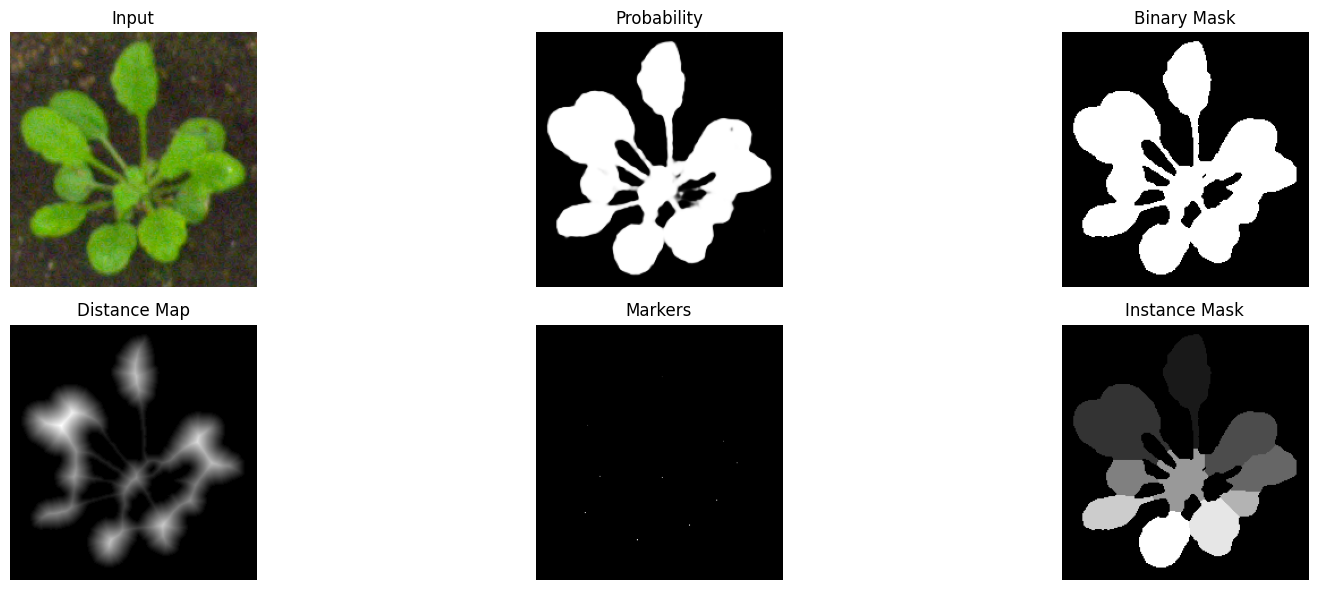

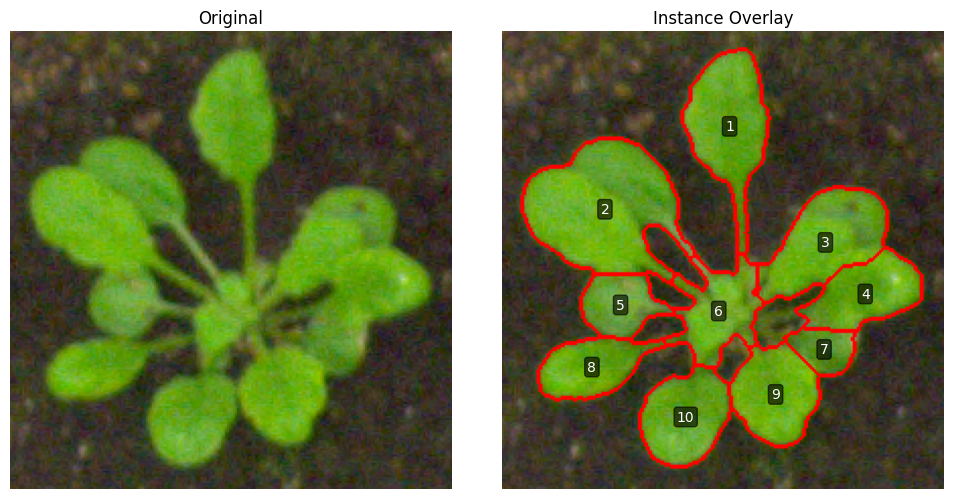

In [14]:
viz = Stage2Visualizer()
viz.show_pipeline(result)
viz.show_overlay(result)

TEST_INDEX = 100          # posisi gambar di daftar sorted
TEST_NAME = None          # atau nama file, contoh: "ara2012_plant150.png"

if TEST_NAME is not None:
    test_path = str(Path("data/imgs") / TEST_NAME)
else:
    test_path = image_paths[TEST_INDEX]

test_image = Image.open(test_path).convert("RGB")
test_result = pipeline.process(test_image)

print(f"Image   : {Path(test_path).name}")
print(f"Size    : {test_image.size[0]}x{test_image.size[1]}")
print(f"Instances: {test_result['instance_mask'].max()}")

viz.show_pipeline(test_result)
viz.show_overlay(test_result)

## 4b. Test Gambar Lain

Ganti `TEST_INDEX` (0–346) atau isi `TEST_NAME` dengan nama file untuk menguji gambar lain dari `data/imgs`.

Image   : ara2012_plant007.png
Size    : 233x213
Instances: 12


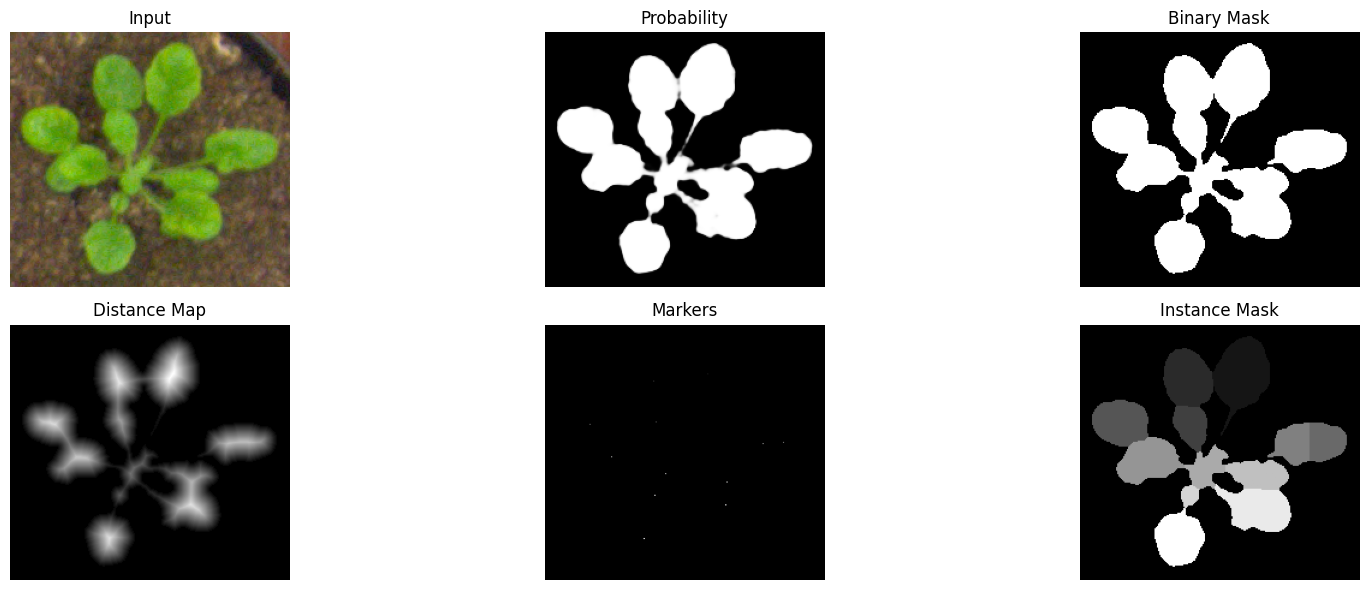

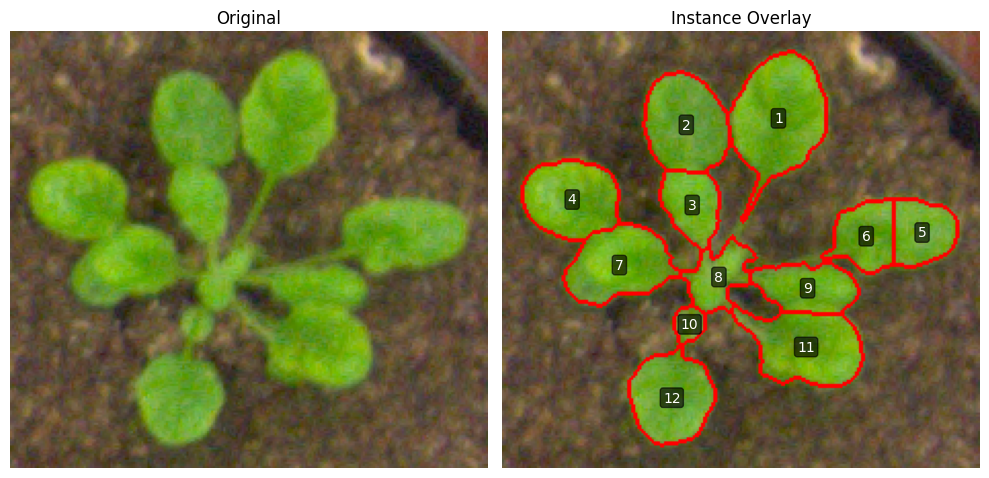

In [29]:
TEST_INDEX = 6          # posisi gambar di daftar sorted
TEST_NAME = None          # atau nama file, contoh: "ara2012_plant150.png"

if TEST_NAME is not None:
    test_path = str(Path("data/imgs") / TEST_NAME)
else:
    test_path = image_paths[TEST_INDEX]

test_image = Image.open(test_path).convert("RGB")
test_result = pipeline.process(test_image)

print(f"Image   : {Path(test_path).name}")
print(f"Size    : {test_image.size[0]}x{test_image.size[1]}")
print(f"Instances: {test_result['instance_mask'].max()}")

viz.show_pipeline(test_result)
viz.show_overlay(test_result)

## 5. Batch Processing

In [15]:
sample_paths = image_paths[:20]
sample_images = [Image.open(p).convert("RGB") for p in sample_paths]

results = pipeline.process_batch(sample_images)

for i, (path, result) in enumerate(zip(sample_paths, results)):
    n = result["instance_mask"].max()
    print(f"{Path(path).name}: {n} instances")

ara2012_plant001.png: 10 instances
ara2012_plant002.png: 12 instances
ara2012_plant003.png: 14 instances
ara2012_plant004.png: 12 instances
ara2012_plant005.png: 8 instances
ara2012_plant006.png: 14 instances
ara2012_plant007.png: 12 instances
ara2012_plant008.png: 11 instances
ara2012_plant009.png: 11 instances
ara2012_plant010.png: 11 instances
ara2012_plant011.png: 8 instances
ara2012_plant012.png: 12 instances
ara2012_plant013.png: 15 instances
ara2012_plant014.png: 16 instances
ara2012_plant015.png: 15 instances
ara2012_plant016.png: 10 instances
ara2012_plant017.png: 13 instances
ara2012_plant018.png: 12 instances
ara2012_plant019.png: 15 instances
ara2012_plant020.png: 12 instances


## 6. Evaluate vs Ground Truth

In [16]:
from stage2.preprocessing import Stage2Preprocessor

preprocessor = Stage2Preprocessor(target_size=config.target_size)
evaluator = Stage2Evaluator()

gt_masks = []
for p, result in zip(sample_paths, results):
    mask_path = Path("data/masks") / Path(p).name
    if mask_path.exists():
        h, w = result["instance_mask"].shape
        gt = preprocessor.preprocess_mask(
            Image.open(mask_path), target_size=(w, h)
        )
        gt_masks.append(gt)
    else:
        gt_masks.append(None)

valid = [(r, g) for r, g in zip(results, gt_masks) if g is not None]
if valid:
    metrics = evaluator.evaluate_batch(
        [v[0] for v in valid], [v[1] for v in valid]
    )
    print(f"Mean F1: {metrics['mean_f1']:.4f}")
    print(f"Mean IoU: {metrics['mean_iou']:.4f}")
    print(f"Mean Precision: {metrics['mean_precision']:.4f}")
    print(f"Mean Recall: {metrics['mean_recall']:.4f}")
    print(f"Mean Count Error: {metrics['mean_count_error']:.2f}")
else:
    print("No ground truth masks found for evaluation")

Mean F1: 0.8915
Mean IoU: 0.7450
Mean Precision: 1.0000
Mean Recall: 0.8100
Mean Count Error: -2.85


## 7. Parameter Experiments

In [21]:
from stage2.prediction import Stage1Predictor

predictor = Stage1Predictor.from_checkpoint(CHECKPOINT)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
min_distances = [5, 10, 15, 20]

print("Threshold | MinDist | Mean Instances")
print("-" * 40)
for t in thresholds:
    for md in min_distances:
        cfg = WatershedConfig(
            probability_threshold=t,
            min_distance=md,
        )
        p = Stage2Pipeline(predictor, config=cfg)
        batch_results = p.process_batch(sample_images[:5])
        avg_instances = sum(
            r["instance_mask"].max() for r in batch_results
        ) / len(batch_results)
        print(f"  {t:.1f}     |   {md:2d}    |   {avg_instances:.1f}")

Threshold | MinDist | Mean Instances
----------------------------------------
  0.3     |    5    |   14.0
  0.3     |   10    |   11.4
  0.3     |   15    |   9.6
  0.3     |   20    |   9.0
  0.4     |    5    |   14.0
  0.4     |   10    |   11.4
  0.4     |   15    |   9.8
  0.4     |   20    |   9.0
  0.5     |    5    |   13.0
  0.5     |   10    |   11.2
  0.5     |   15    |   9.6
  0.5     |   20    |   9.0
  0.6     |    5    |   14.2
  0.6     |   10    |   10.6
  0.6     |   15    |   9.8
  0.6     |   20    |   9.0
  0.7     |    5    |   14.4
  0.7     |   10    |   10.4
  0.7     |   15    |   9.8
  0.7     |   20    |   9.0


## 8. Save Results

In [23]:
import shutil
import os
import stat


def _remove_readonly(func, path, _):
    os.chmod(path, stat.S_IWRITE)
    func(path)


output_dir = Path("predictions/stage2")
if output_dir.exists():
    shutil.rmtree(output_dir, onerror=_remove_readonly)
output_dir.mkdir(parents=True, exist_ok=True)

for i, (path, result) in enumerate(zip(sample_paths, results)):
    prefix = f"{i:04d}_{Path(path).stem}_"
    pipeline.save_results(result, str(output_dir), prefix=prefix)

print(f"Saved {len(results)} results to {output_dir}")

Saved 20 results to predictions\stage2
